In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [149]:
def generate_data(num_samples):
    X = np.random.randn(num_samples,1)*10
    y = 3*X + 7 + np.random.randn(num_samples,1)
    return X, y

In [150]:
def compute_loss(y_true,y_pred):
    return np.mean((y_true - y_pred)**2)

In [159]:
X, y = generate_data(50)

In [166]:
theta_ = np.random.randn(X.shape[1]+1, 1)

In [167]:
class Batch_GD:
    def __init__(self, parameters, epochs=100, lr=0.01, print_on_step=None):
        self.n_epochs = epochs
        self.lr = lr
        self.theta_ = parameters
        self.print_on_step = print_on_step

        self.loss_history = []
    
    def optimize(self, X, y):
        n_points, n_features = X.shape
        X = np.c_[np.ones((n_points,1)),X]

        for epoch in range(self.n_epochs):
            # calculate prediction
            y_pred = np.dot(X, self.theta_)
            # calculate gradient
            error = y - y_pred
            gradient = -(2/n_points) * np.dot(X.T,error)
            # calculate loss
            loss = compute_loss(y, y_pred)
            # weight update
            self.theta_ -= self.lr * gradient

            if self.print_on_step:
                if(epoch+1)%self.print_on_step==0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")
            self.loss_history.append(loss)



In [168]:
batch_gd = Batch_GD(theta_, 1000, 0.01, 10)

In [169]:
batch_gd.optimize(X,y)

Epoch: 9, Loss: 42.2680
Epoch: 19, Loss: 28.6107
Epoch: 29, Loss: 19.4682
Epoch: 39, Loss: 13.3480
Epoch: 49, Loss: 9.2509
Epoch: 59, Loss: 6.5083
Epoch: 69, Loss: 4.6723
Epoch: 79, Loss: 3.4432
Epoch: 89, Loss: 2.6205
Epoch: 99, Loss: 2.0697
Epoch: 109, Loss: 1.7010
Epoch: 119, Loss: 1.4541
Epoch: 129, Loss: 1.2889
Epoch: 139, Loss: 1.1783
Epoch: 149, Loss: 1.1043
Epoch: 159, Loss: 1.0547
Epoch: 169, Loss: 1.0215
Epoch: 179, Loss: 0.9993
Epoch: 189, Loss: 0.9844
Epoch: 199, Loss: 0.9745
Epoch: 209, Loss: 0.9678
Epoch: 219, Loss: 0.9634
Epoch: 229, Loss: 0.9604
Epoch: 239, Loss: 0.9584
Epoch: 249, Loss: 0.9570
Epoch: 259, Loss: 0.9561
Epoch: 269, Loss: 0.9555
Epoch: 279, Loss: 0.9551
Epoch: 289, Loss: 0.9549
Epoch: 299, Loss: 0.9547
Epoch: 309, Loss: 0.9546
Epoch: 319, Loss: 0.9545
Epoch: 329, Loss: 0.9544
Epoch: 339, Loss: 0.9544
Epoch: 349, Loss: 0.9544
Epoch: 359, Loss: 0.9544
Epoch: 369, Loss: 0.9544
Epoch: 379, Loss: 0.9543
Epoch: 389, Loss: 0.9543
Epoch: 399, Loss: 0.9543
Epoch: 

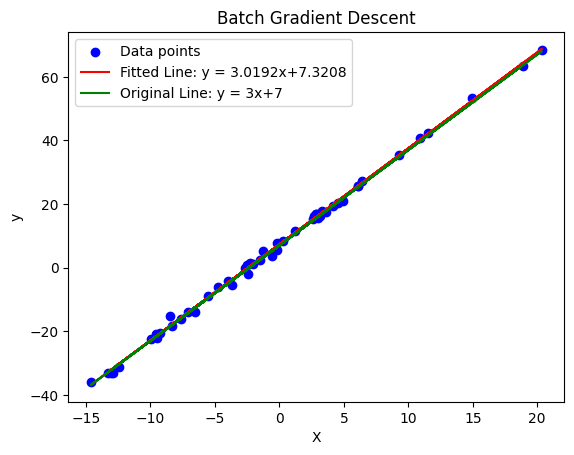

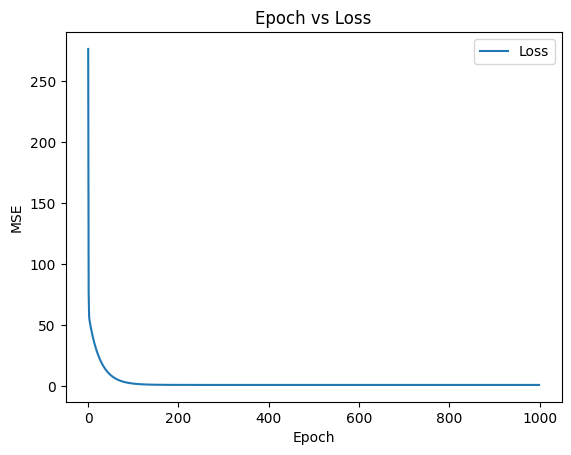

In [170]:
c, m = batch_gd.theta_
plt.scatter(X,y,label=f'Data points',color='blue')
plt.plot(X,np.c_[np.ones((X.shape[0],1)),X].dot(batch_gd.theta_),label=f'Fitted Line: y = {m[0]:.4f}x+{c[0]:.4f}',color='red')
plt.plot(X,3*X+7,label=f'Original Line: y = 3x+7',color='green')
plt.title('Batch Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.plot(batch_gd.loss_history,label='Loss')
plt.title('Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()
